In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("car_data.csv")
df.head()

,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,Honda,City,2001,23,"98,000 km",Manual,second,Petrol,Nov-24,"Honda City v teck in mint condition, valid gen...","₹ 1,95,000"
1,Toyota,Innova,2009,15,190000.0 km,Manual,second,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...","₹ 3,75,000"
2,Volkswagen,VentoTest,2010,14,"77,246 km",Manual,first,Diesel,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...","₹ 1,84,999"
3,Maruti Suzuki,Swift,2017,7,"83,500 km",Manual,second,Diesel,Nov-24,Maruti Suzuki Swift 2017 Diesel Good Condition,"₹ 5,65,000"
4,Maruti Suzuki,Baleno,2019,5,"45,000 km",Automatic,first,Petrol,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol","₹ 6,85,000"


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9582 entries, 0 to 9581
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Brand         9582 non-null   object
 1   model         9582 non-null   object
 2   Year          9582 non-null   int64 
 3   Age           9582 non-null   int64 
 4   kmDriven      9535 non-null   object
 5   Transmission  9582 non-null   object
 6   Owner         9582 non-null   object
 7   FuelType      9582 non-null   object
 8   PostedDate    9582 non-null   object
 9   AdditionInfo  9582 non-null   object
 10  AskPrice      9582 non-null   object
dtypes: int64(2), object(9)
memory usage: 823.6+ KB


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

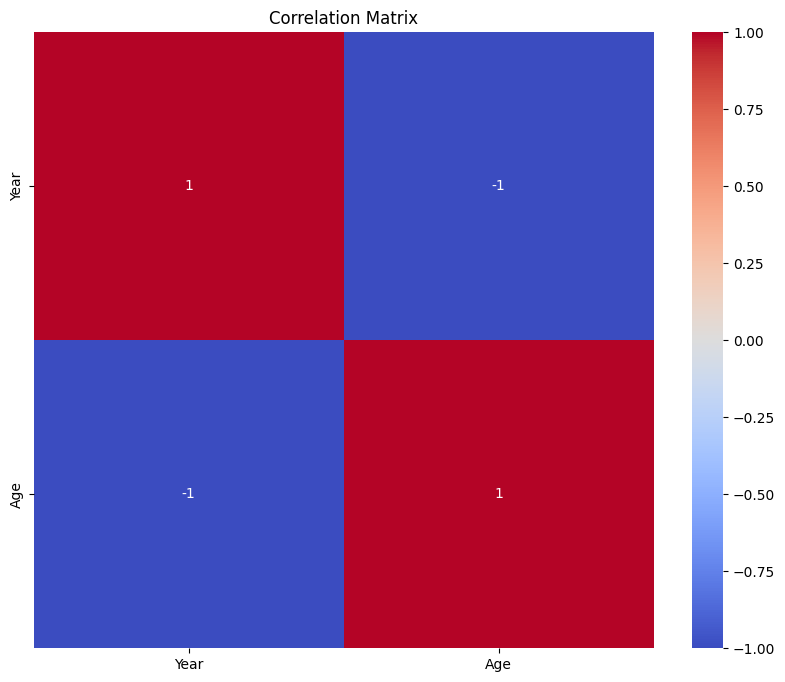

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [13]:
df.select_dtypes(include=['number'])

,Year,Age
0,2001,23
1,2009,15
2,2010,14
3,2017,7
4,2019,5
...,...,...
9577,2014,10
9578,2020,4
9579,2013,11
9580,2019,5


In [15]:
print(df.columns.tolist())

['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner', 'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice']


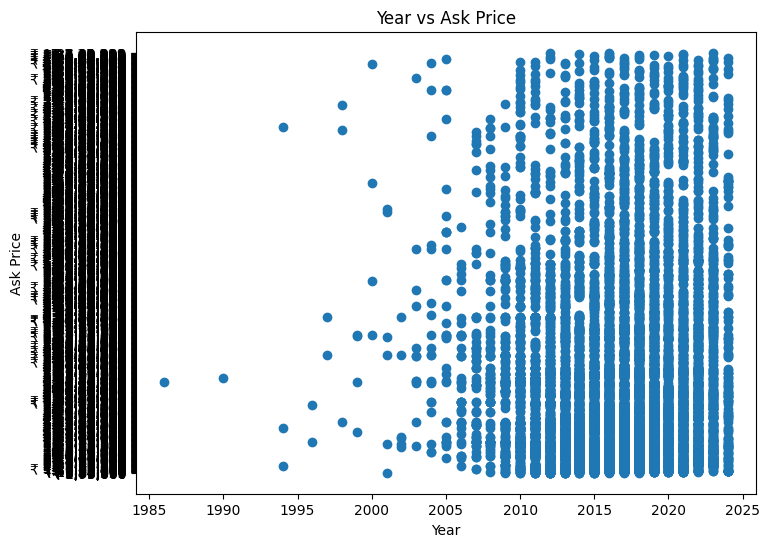

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(df["Year"], df["AskPrice"])
plt.xlabel("Year")
plt.ylabel("Ask Price")
plt.title("Year vs Ask Price")
plt.show()

In [19]:
import pandas as pd

df = pd.read_csv("car_data.csv")
print(df.columns)

Index(['Brand', 'model', 'Year', 'Age', 'kmDriven', 'Transmission', 'Owner',
       'FuelType', 'PostedDate', 'AdditionInfo', 'AskPrice'],
      dtype='object')


In [20]:
y = df["AskPrice"]
X = df.drop("AskPrice", axis=1)

In [22]:
X = X.drop(["Brand", "model", "PostedDate", "AdditionInfo"], axis=1)

In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
import pandas as pd

df = pd.read_csv("car_data.csv")

In [28]:
# Remove currency symbol and commas
df["AskPrice"] = df["AskPrice"].str.replace("₹", "", regex=False)
df["AskPrice"] = df["AskPrice"].str.replace(",", "", regex=False)

# Convert to float
df["AskPrice"] = df["AskPrice"].astype(float)

df["AskPrice"].head()

0    195000.0
1    375000.0
2    184999.0
3    565000.0
4    685000.0
Name: AskPrice, dtype: float64

In [29]:
# Separate target
y = df["AskPrice"]
X = df.drop("AskPrice", axis=1)

# Drop text-heavy columns
X = X.drop(["Brand", "model", "PostedDate", "AdditionInfo"], axis=1)

# Encode categorical columns
X = pd.get_dummies(X, drop_first=True)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

R2 Score: 0.14021676715287346
Mean Absolute Error: 559282.0703717698
Root Mean Squared Error: 1518121.1796517004


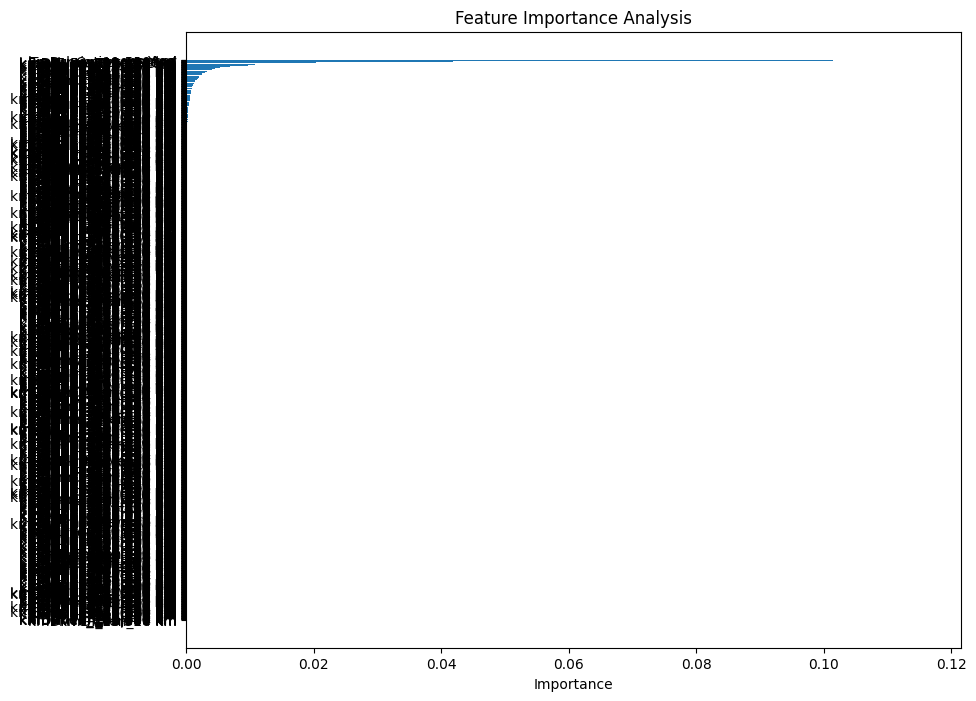

In [35]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from trained model
importance = model.feature_importances_

# Get feature names from training data
feature_names = X.columns

# Create dataframe for better visualization
feature_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_df = feature_df.sort_values(by="Importance", ascending=True)

# Plot
plt.figure(figsize=(10,8))
plt.barh(feature_df["Feature"], feature_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance Analysis")
plt.show()

In [36]:
import pandas as pd

# Create sample data (adjust values based on your dataset)
sample_data = pd.DataFrame({
    "Year": [2018],
    "Age": [5],
    "kmDriven": [45000],
    "Transmission_Manual": [1],
    "Owner_Second": [0],
    "FuelType_Diesel": [1]
})

In [37]:
# Add missing columns with value 0
sample_data = sample_data.reindex(columns=X.columns, fill_value=0)

In [38]:
predicted_price = model.predict(sample_data)

print("Predicted Price: ₹", round(predicted_price[0], 2))

Predicted Price: ₹ 799767.39


In [39]:
import joblib

joblib.dump(model, "car_price_model.pkl")

['car_price_model.pkl']

In [40]:
joblib.dump(X.columns, "model_columns.pkl")

['model_columns.pkl']